# Mixture Transform Builder Demo

This notebook demonstrates the new `numpyro_extras` mixture-transform pipeline:

1. Build transforms from a Gaussian mixture (`base="normal"` and `base="uniform"`).
2. Inspect diagnostics/config metadata.
3. Visualize distribution fit and calibration.
4. Check roundtrip accuracy and Jacobian behavior.

## Imports And Setup

This cell adds `../src` to `sys.path` so the local package can be imported directly from the repository.

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from numpyro.distributions import Categorical, MixtureSameFamily, Normal

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from numpyro_extras.mixture_transform_builder import (
    MixtureTransformBuildConfig,
    build_mixture_transform,
)

jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

/Users/holtw/Documents/mydocs/software/numpyro-extras/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define A Target Mixture

In [28]:
weights = jnp.array([0.05, 0.35, 0.3, 0.3], dtype=jnp.float64)
loc = jnp.array([-1.5, 2.0, 4.0, 0.0], dtype=jnp.float64)
scale = jnp.array([0.1, 1.2, 0.5, 3.0], dtype=jnp.float64)

mixture = MixtureSameFamily(
    Categorical(probs=weights),
    Normal(loc=loc, scale=scale),
)

print("weights:", weights)
print("loc:", loc)
print("scale:", scale)

weights: [0.05 0.35 0.3  0.3 ]
loc: [-1.5  2.   4.   0. ]
scale: [0.1 1.2 0.5 3. ]


## Build Normal-Base And Uniform-Base Transforms

Note: use `mixture=...` (not `mixture_distribution=...`) for the default object-mode call path.

In [29]:
cfg = MixtureTransformBuildConfig(knot_cfg={"num_knots": 2049})

normal_result = build_mixture_transform(
    base="normal",
    mixture=mixture,
    build_cfg=cfg,
)
uniform_result = build_mixture_transform(
    base="uniform",
    mixture=mixture,
    build_cfg=cfg,
)

normal_transform = normal_result.transform
uniform_transform = uniform_result.transform

print("Normal metadata keys:", sorted(normal_result.metadata.keys()))
print("Normal diagnostics keys:", sorted(normal_result.diagnostics.keys()))
print("Approximation summary (normal):")
for k, v in normal_result.diagnostics["approximation"].items():
    print(f"  {k}: {v}")

Normal metadata keys: ['base', 'input_mode', 'num_components', 'stitch_provenance', 'weights_shape']
Normal diagnostics keys: ['approximation', 'backend', 'config', 'interpolation', 'knot']
Approximation summary (normal):
  finite_forward: True
  finite_inverse: True
  roundtrip_max_abs_error: 9.115840526874308e-09
  roundtrip_mean_abs_error: 6.916257165217748e-11
  roundtrip_interior_max_abs_error: 2.2319923687064147e-12
  monotone_forward: True
  mixture_cdf_grid_min: 1.6205584968833025e-08
  mixture_cdf_grid_max: 0.999999983794414


## Plot 1: Density Match

Compare transformed normal samples against direct mixture samples and the analytic mixture PDF.

In [30]:
normal_transform(0.001)

Array(2.3508, dtype=float64)

In [31]:
normal_result.transform.interpolator.base.u_knots

Array([0., 0., 0., ..., 1., 1., 1.], dtype=float64)

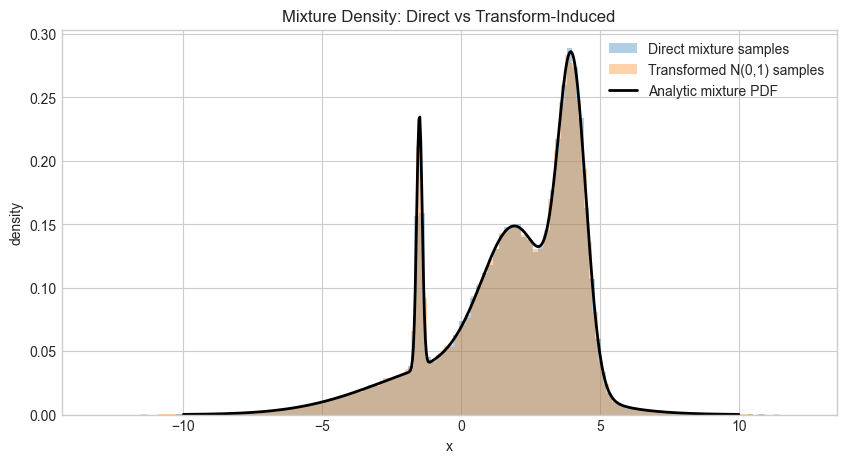

In [33]:
key = jax.random.PRNGKey(2026)
key_z, key_x = jax.random.split(key)

n = 100000
z_samples = jax.random.normal(key_z, shape=(n,), dtype=jnp.float64)
x_from_transform = normal_transform(z_samples)
x_direct = mixture.sample(key_x, sample_shape=(n,))

x_grid = jnp.linspace(-10.0, 10.0, 600, dtype=jnp.float64)
pdf_grid = jnp.exp(mixture.log_prob(x_grid))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.asarray(x_direct), bins=120, density=True, alpha=0.35, label="Direct mixture samples")
ax.hist(np.asarray(x_from_transform), bins=120, density=True, alpha=0.35, label="Transformed N(0,1) samples")
ax.plot(np.asarray(x_grid), np.asarray(pdf_grid), color="black", lw=2.0, label="Analytic mixture PDF")
ax.set_title("Mixture Density: Direct vs Transform-Induced")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend(loc="upper right")
plt.show()

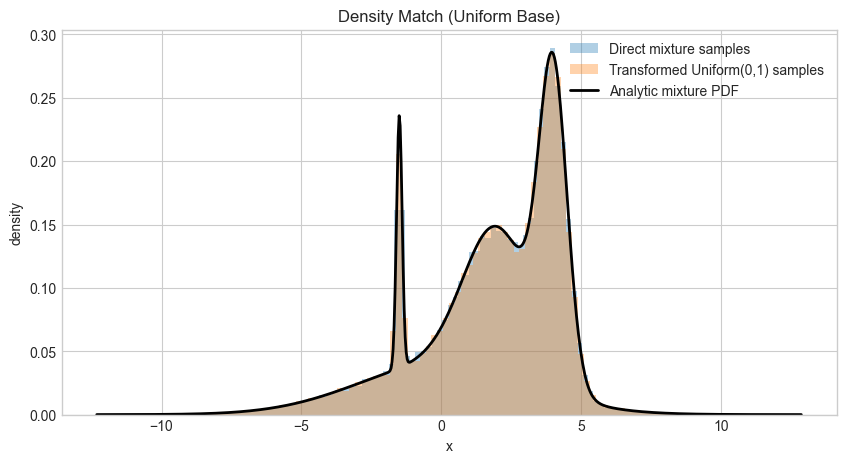

In [36]:
# density match for uniform
key = jax.random.PRNGKey(2027)
key_u, key_x = jax.random.split(key)

n = 100000
u_samples = jax.random.uniform(
    key_u,
    shape=(n,),
    minval=jnp.asarray(1e-9, dtype=jnp.float64),
    maxval=jnp.asarray(1.0 - 1e-9, dtype=jnp.float64),
)
x_from_uniform_transform = uniform_transform(u_samples)
x_direct_uniform = mixture.sample(key_x, sample_shape=(n,))

x_all = jnp.concatenate([x_from_uniform_transform, x_direct_uniform])
x_grid = jnp.linspace(jnp.min(x_all), jnp.max(x_all), 700)
pdf_grid = jnp.exp(mixture.log_prob(x_grid))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    np.asarray(x_direct_uniform),
    bins=120,
    density=True,
    alpha=0.35,
    label="Direct mixture samples",
)
ax.hist(
    np.asarray(x_from_uniform_transform),
    bins=120,
    density=True,
    alpha=0.35,
    label="Transformed Uniform(0,1) samples",
)
ax.plot(np.asarray(x_grid), np.asarray(pdf_grid), "k-", lw=2, label="Analytic mixture PDF")
ax.set_title("Density Match (Uniform Base)")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend(loc="best")
plt.show()

In [ ]:
# dentiy match for uniform

## Plot 2: CDF Calibration

For `z -> x = T(z)`, we should have `Phi(z) ~= F_mix(x)`.

In [ ]:
u_grid = jnp.linspace(1e-6, 1.0 - 1e-6, 800, dtype=jnp.float64)
x_grid_uniform = uniform_transform(u_grid)
mix_cdf_uniform = mixture.cdf(x_grid_uniform)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(u_grid, x_grid_uniform, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(u_grid, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(mix_cdf_uniform, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(np.asarray(u_grid), np.asarray(mix_cdf_uniform), lw=2.0, label=r"$F_{mix}(T(u))$")
ax.plot([0, 1], [0, 1], "--", color="gray", label="ideal")
ax.set_title("CDF Calibration (Uniform Base)")
ax.set_xlabel(r"$u$")
ax.set_ylabel(r"$F_{mix}(T(u))$")
ax.legend(loc="lower right")
ax.set_aspect("equal", adjustable="box")
plt.show()

calibration_err_uniform = jnp.max(jnp.abs(u_grid - mix_cdf_uniform))
print("max |u - F_mix(T(u))|:", float(calibration_err_uniform))

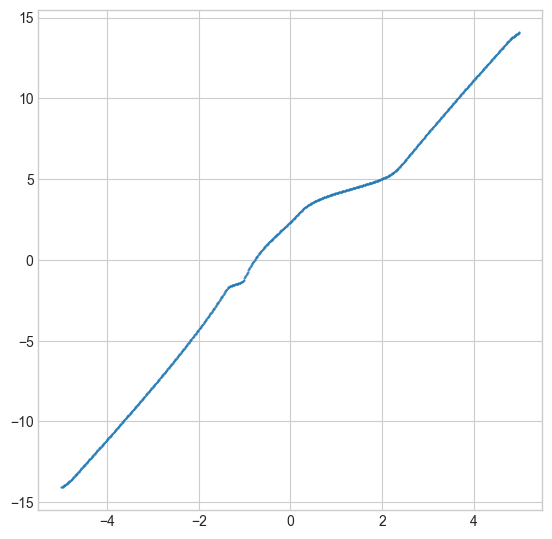

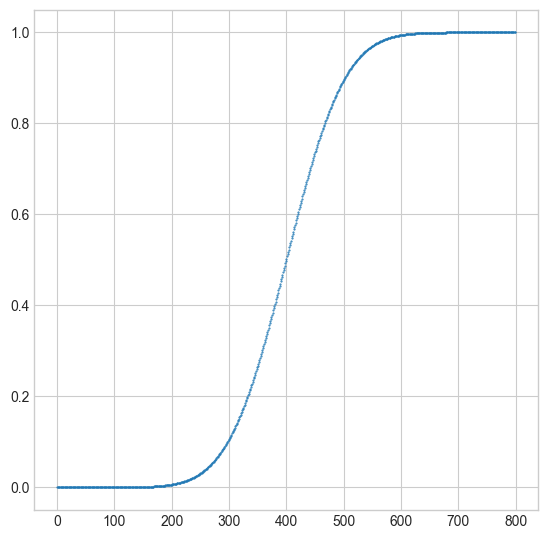

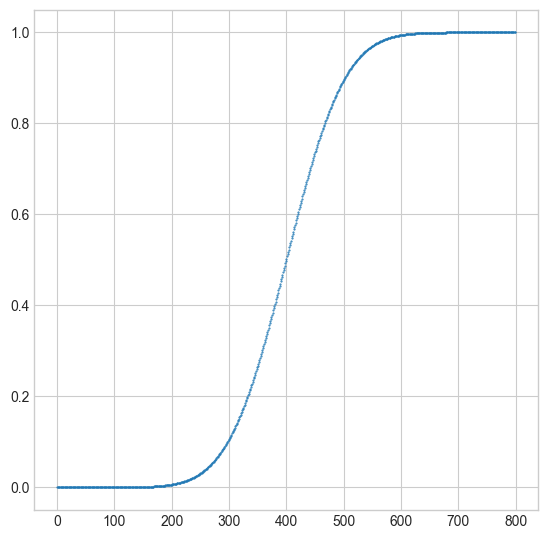

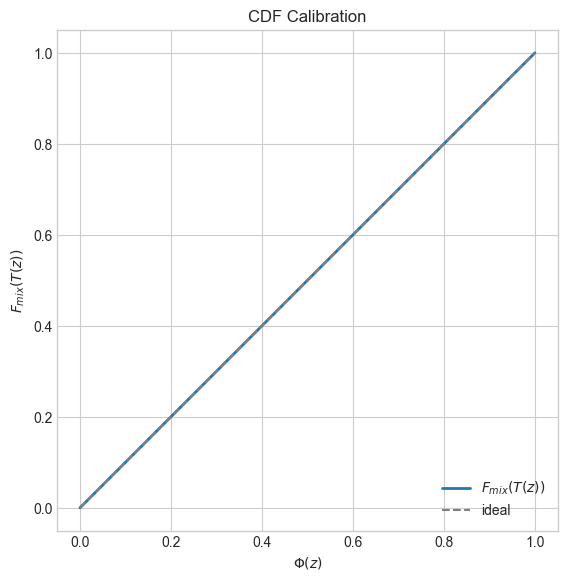

max |Phi(z) - F_mix(T(z))|: 3.321543986917197e-05


In [35]:
std_normal = Normal(jnp.array(0.0, dtype=jnp.float64), jnp.array(1.0, dtype=jnp.float64))

z_grid = jnp.linspace(-5.0, 5.0, 800, dtype=jnp.float64)
x_grid = normal_transform(z_grid)
phi_cdf = std_normal.cdf(z_grid)
mix_cdf = mixture.cdf(x_grid)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(z_grid, x_grid, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(phi_cdf, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(mix_cdf, lw=0, marker='.', ms=1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(np.asarray(phi_cdf), np.asarray(mix_cdf), lw=2.0, label=r"$F_{mix}(T(z))$")
ax.plot([0, 1], [0, 1], "--", color="gray", label="ideal")
ax.set_title("CDF Calibration")
ax.set_xlabel(r"$\Phi(z)$")
ax.set_ylabel(r"$F_{mix}(T(z))$")
ax.legend(loc="lower right")
ax.set_aspect("equal", adjustable="box")
plt.show()

calibration_err = jnp.max(jnp.abs(phi_cdf - mix_cdf))
print("max |Phi(z) - F_mix(T(z))|:", float(calibration_err))

## Plot 3: Roundtrip Error (Uniform + Normal)

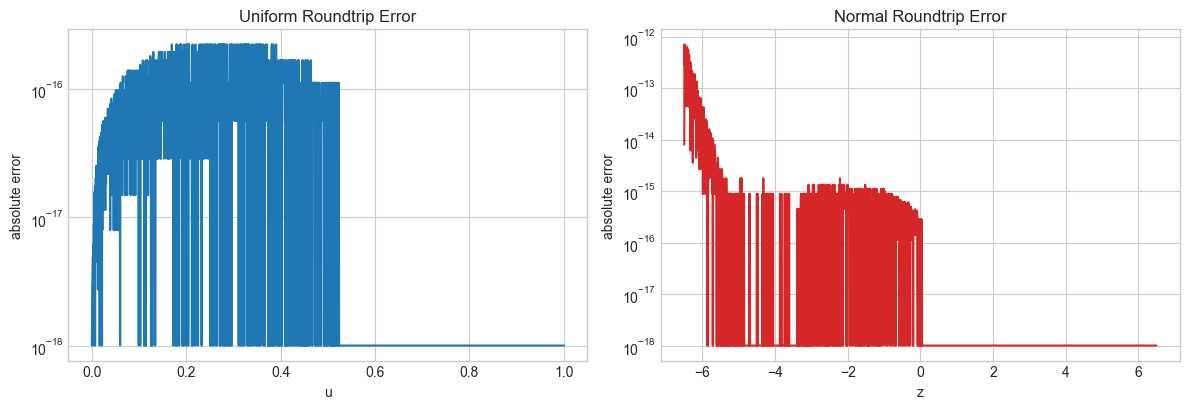

max uniform roundtrip error: 2.220446049250313e-16
max normal roundtrip error: 7.096545573404001e-13


In [10]:
u_grid = jnp.linspace(1e-6, 1.0 - 1e-6, 3000, dtype=jnp.float64)
u_roundtrip = uniform_transform._inverse(uniform_transform(u_grid))
u_err = jnp.abs(u_roundtrip - u_grid)

z_grid = jnp.linspace(-6.5, 6.5, 3000, dtype=jnp.float64)
y_grid = normal_transform(z_grid)
z_roundtrip = normal_transform._inverse(y_grid)

clip_eps = cfg.transform_cfg.clip_u_eps
z_expected = std_normal.icdf(jnp.clip(std_normal.cdf(z_grid), clip_eps, 1.0 - clip_eps))
z_err = jnp.abs(z_roundtrip - z_expected)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(np.asarray(u_grid), np.asarray(u_err + 1e-18), color="#1f77b4")
ax[0].set_title("Uniform Roundtrip Error")
ax[0].set_xlabel("u")
ax[0].set_ylabel("absolute error")

ax[1].semilogy(np.asarray(z_grid), np.asarray(z_err + 1e-18), color="#d62728")
ax[1].set_title("Normal Roundtrip Error")
ax[1].set_xlabel("z")
ax[1].set_ylabel("absolute error")

plt.tight_layout()
plt.show()

print("max uniform roundtrip error:", float(jnp.max(u_err)))
print("max normal roundtrip error:", float(jnp.max(z_err)))

## Plot 4: Normal-Base Log|det J|

For `z -> x`, the Jacobian should be finite and smooth.

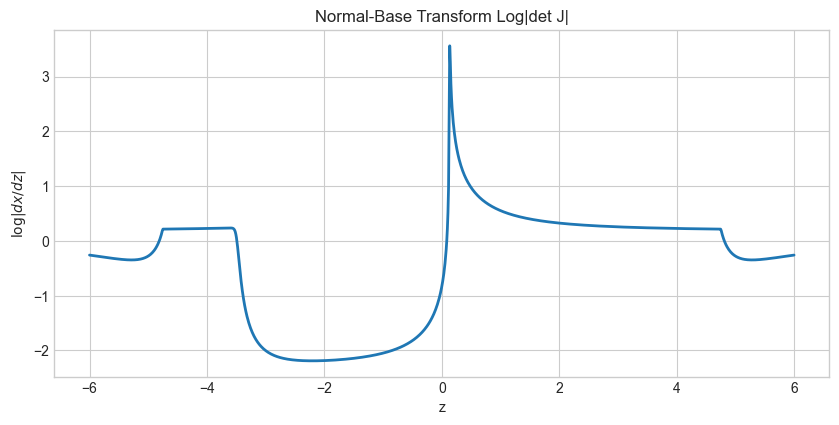

finite log-det values: True


In [11]:
z_grid = jnp.linspace(-6.0, 6.0, 1200, dtype=jnp.float64)
y_grid = normal_transform(z_grid)
log_det = normal_transform.log_abs_det_jacobian(z_grid, y_grid)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.asarray(z_grid), np.asarray(log_det), lw=2.0)
ax.set_title("Normal-Base Transform Log|det J|")
ax.set_xlabel("z")
ax.set_ylabel(r"$\log |dx/dz|$")
plt.show()

print("finite log-det values:", bool(jnp.all(jnp.isfinite(log_det))))

## Custom Configuration Example

You can override defaults by creating a custom `MixtureTransformBuildConfig`.

In [12]:
custom_cfg = MixtureTransformBuildConfig(
    knot_cfg=cfg.knot_cfg.__class__(num_knots=129, grid_type="logit_u"),
    interp_cfg=cfg.interp_cfg.__class__(
        interior_method="akima",
        clip_u_eps=1e-12,
        safe_arctanh_eps=1e-7,
    ),
)

custom_result = build_mixture_transform(
    base="normal",
    mixture=mixture,
    build_cfg=custom_cfg,
)

print("custom num_knots:", custom_result.diagnostics["knot"].get("requested_num_knots"))
print("custom stitch provenance:", custom_result.diagnostics["interpolation"]["boundary_slope_source"])

custom num_knots: 129
custom stitch provenance: interior_boundary_gradient
